#### Assignment 4: Markov Chain Monte Carlo (MCMC)

**Members: Cui(Cathy) Yu, Shravani Mahadeshwar, Priya Botsa, Marc Hayes, Shaonan Feng and Di Yang**

- *Course: Machine Learning 2*
- *Prof: Jan Nagler*
- *Due: 17 May 2026*



The devised program estimates robustly, given very noisy and very sparse data of infected and recovered of a past epidemic, the basic reproduction number of the SIR model. To keep computation in limit, we assume gamma=1. The SIR model is implemented in a minimal and optimal way, using scaled variables and a scaled time. Only the ODE part is numerically integrated that needs to be integrated. The noisy number of infected and the number of recovered are highly correlated. This relationship helps MCMC infer the parameters.

Get familiar with the commented MCMC code below.

---

**Task**:
Change the program to the SIRD model, by including (D)eaths, with rate $\mu$. Fix not only $\gamma=1$ but also $\beta=2.5$ (or to a higher value of your choice).
Infer the death rate $\mu$, given noisy $S(t)$, $I(t)$, $R(t)$, $D(t)$ input curves.
If you want, you can try to optimze the code (optional, very very hard).
Also optional is: Does the inference for $\mu$ work, if $S(t)$ and/or $R(t)$ are not given ?
You may use these (initial) conditions/parameters: $$i0 = 0.01, s0 = 0.99, r0 = 0, d0 = 0, f = 3.0, timestep = 0.5.$$
You may assume values for the respective $\sigma$'s (log-normal noises) in the range of $0.2-0.4$, but not lower than $0.1$. For assessment use HPD plots, or similar. Good luck and have fun.

**Step 1: Import and Settings**

In [10]:
# macOS / PyTensor compiler workaround. Run this BEFORE importing pymc.
# It fixes cases where clang++ cannot find the C++ standard library header <vector>.
import os
import sys
import subprocess

if sys.platform == "darwin":
    try:
        sdk = subprocess.check_output(["xcrun", "--show-sdk-path"], text=True).strip()
        os.environ.setdefault("SDKROOT", sdk)
        import pytensor
        pytensor.config.cxx = "/usr/bin/clang++"
        pytensor.config.gcc__cxxflags = f"-I{sdk}/usr/include/c++/v1"
        print("Configured PyTensor C++ flags for macOS SDK:", pytensor.config.gcc__cxxflags)
    except Exception as exc:
        print("Could not configure PyTensor compiler workaround:", repr(exc))


Configured PyTensor C++ flags for macOS SDK: -I/Library/Developer/CommandLineTools/SDKs/MacOSX.sdk/usr/include/c++/v1


In [2]:
# Assignment 4: SIRD model, MCMC for mu
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_theme()
import pymc as pm #install if necessary
from pymc.ode import DifferentialEquation
from scipy.integrate import odeint
import warnings
warnings.filterwarnings("ignore")
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
np.random.seed(42)

/Applications/anaconda3/envs/DataAnalytics/lib/python3.13/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


**Step 2: Defining SIRD ODE**

The SIRD model extends the classic SIR model by adding a **Deaths (D)** compartment. The system of ODEs is:

$$\frac{dS}{dt} = -\beta S I$$

$$\frac{dI}{dt} = \beta S I - \gamma I - \mu I$$

$$\frac{dR}{dt} = \gamma I$$

$$\frac{dD}{dt} = \mu I$$

| Parameter | Value | Role |
|-----------|-------|------|
| β | 2.5 (fixed) | Transmission rate |
| γ | 1.0 (fixed) | Recovery rate |
| μ | **inferred** | Death/mortality rate |

**Initial conditions:** s₀ = 0.99, i₀ = 0.01, r₀ = 0, d₀ = 0

In [9]:
# Define initial conditions of SIRD model
s0=0.99
i0 = 0.01 #fractions infected at time t0=0 (1%)
r0 = 0.00 #fraction of recovered at time t0=0
d0=0.00 #fraction of recovered at time t0=0
f = 3 #3.0 # time factor, defines total time window range
timestep_data = 0.5 # dt for data (e.g., weekly)

# ODE SIRD system: dS/dt = -beta*S*I, dI/dt = beta*S*I - gamma*I - mu*I, dR/dt = gamma*I, dD/dt = mu*I
# beta = 2.5, gamma = 1.0 are fixed, mu is inferred (p[0])
def SIRD(y, t, p):
    s = y[0] # Susceptible
    i = y[1] # Infected
    r = y[2] # Recovered
    d = y[3] # Dead

    mu_infer = p[0] # The parameter to be inferred is mu
    beta_fixed = 2.5 # Fixed beta as per task
    gamma_fixed = 1.0 # Fixed gamma as per task

    ds_dt = -beta_fixed * s * i
    di_dt = beta_fixed * s * i - gamma_fixed * i - mu_infer * i
    dr_dt = gamma_fixed * i
    dd_dt = mu_infer * i
    return [ds_dt, di_dt, dr_dt, dd_dt] # Return derivatives in order of states: S, I, R, D

times = np.arange(0,5*f,timestep_data)

#ground truth (fixed gamma=1, then R0=beta, time scale to t/gamma)
# This variable is not used in SIRD function, but used for reference


**Step 3: Generating synthetic “true” epidemic curves and add noise**

We generate ground-truth SIRD curves using `odeint` with the true death rate **μ_true = 0.15**, then corrupt each compartment with additive Gaussian noise (σ = 0.2) to simulate realistic, noisy observations.

This lets us verify later whether MCMC recovers the true parameter.

In [11]:
# ODE system container is now defined within the pm.Model context in cell s8QFulNuKeLT

mu_true = 0.15

times = np.arange(0, 5*f, timestep_data)
#create SIRD Curves
solution = odeint(
    SIRD,
    [s0, i0, r0, d0],
    times,
    args=([mu_true],)
)

S_data = solution[:,0]
I_data = solution[:,1]
D_data = solution[:,3]
R_data = solution[:,2]
noise = 0.2

S_obs = S_data + np.random.normal(0, noise, len(S_data))
I_obs = I_data + np.random.normal(0, noise, len(I_data))
R_obs = R_data + np.random.normal(0, noise, len(R_data))
D_obs = D_data + np.random.normal(0, noise, len(D_data))

**Step 4: Building PyMC model**

We use PyMC's `DifferentialEquation` wrapper to embed the SIRD ODE inside a probabilistic model.

**Priors:**
- `μ ~ LogNormal(log(0.1), 0.5)` — enforces μ > 0, broad enough to not dominate
- `σ ~ HalfCauchy(1)` — weakly informative noise prior per compartment

**Likelihood:** Each observed compartment is modeled as `Normal(ODE_prediction, σ)`.

**Sampling settings:** 2000 draws, 1000 tuning steps, 4 chains, target_accept = 0.9

In [12]:
with pm.Model() as model:
    # ODE system container
    sird_model = DifferentialEquation(
        func = SIRD,
        times = np.arange(0,5*f,timestep_data), # Reverted to plain numpy array for times
        n_states = 4, #r(ecovered) and i(nfected) are states
        n_theta = 1, # beta=R0 only parameter
        t0 = 0 # start from zero
    )

    mu = pm.Lognormal("mu", mu=np.log(0.1), sigma=0.5)
    sigma = pm.HalfCauchy("sigma", 1, shape=4)

    sird_curves = sird_model(
        y0=np.array([s0, i0, r0, d0]), # Changed y0 to a NumPy array for better shape inference
        theta=[mu]
    )

    S_hat = sird_curves[:, 0]
    I_hat = sird_curves[:, 1]
    R_hat = sird_curves[:, 2]
    D_hat = sird_curves[:, 3]

    S_like = pm.Normal(
        "S_like",
        mu=S_hat,
        sigma=sigma[0],
        observed=S_obs
    )

    I_like = pm.Normal(
        "I_like",
        mu=I_hat,
        sigma=sigma[1],
        observed=I_obs
    )

    R_like = pm.Normal(
        "R_like",
        mu=R_hat,
        sigma=sigma[2],
        observed=R_obs
    )
    D_like = pm.Normal(
        "D_like",
        mu=D_hat,
        sigma=sigma[3],
        observed=D_obs
    )

In [8]:
with model:
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
        return_inferencedata=True
    )
print(pm.summary(trace, var_names=["mu"]).round(2))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 407 seconds.


    mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
mu  0.12  0.03    0.07     0.18        0.0      0.0    8040.0    4784.0    1.0


**Step 5: Displaying model plots**

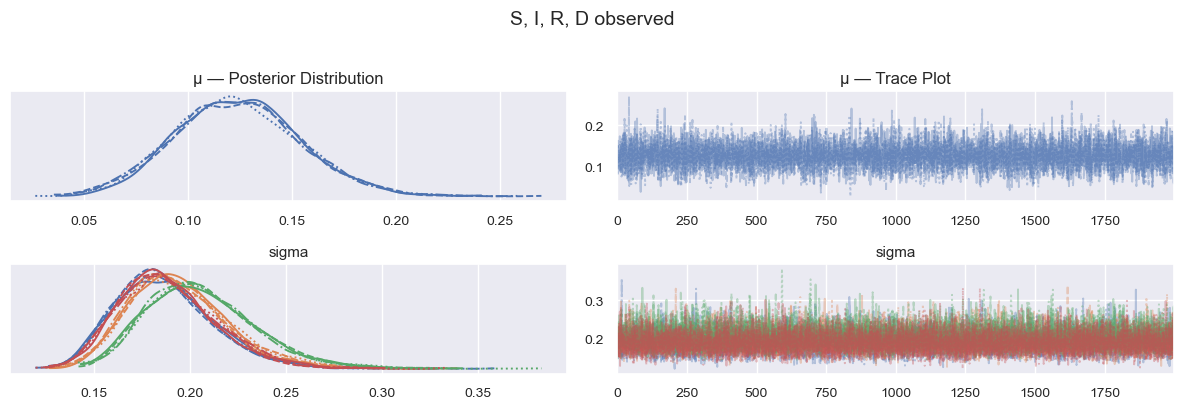

In [14]:
import arviz as az

# Trace plot
axes = az.plot_trace(trace)
axes[0, 0].set_title("μ — Posterior Distribution")   # top-left (KDE)
axes[0, 1].set_title("μ — Trace Plot")                # top-right (trace)
plt.suptitle("S, I, R, D observed", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Posterior plot for μ with true value reference**

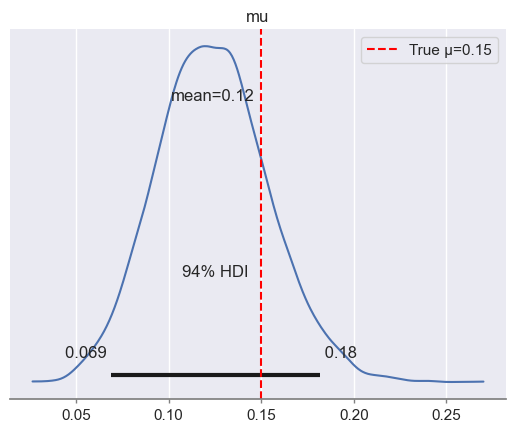

In [ ]:
az.plot_posterior(trace, var_names=["mu"], hdi_prob=0.94)
plt.axvline(mu_true, color='red', linestyle='--', label='True μ=0.15')
plt.legend()

If you want: Further Reading (see slides!), also: https://www.pymc.io/projects/examples/en/latest/diagnostics_and_criticism/Diagnosing_biased_Inference_with_Divergences.html

The following three sections address the optional question:  
> *Does inference for μ work if S(t) and/or R(t) are not given?*

We test three reduced models:
| Model | Observed Compartments |
|-------|-----------------------|
| model1 | I, R, D (no S) |
| model2 | S, I, D (no R) |
| model3 | I, D only |

**Step 6: Reduced model - no S observed**

In [16]:
with pm.Model() as model1:
    # ODE system container
    sird_model = DifferentialEquation(
        func = SIRD,
        times = np.arange(0,5*f,timestep_data), # Reverted to plain numpy array for times
        n_states = 4, #r(ecovered) and i(nfected) are states
        n_theta = 1, # beta=R0 only parameter
        t0 = 0 # start from zero
    )

    mu = pm.Lognormal("mu", mu=np.log(0.1), sigma=0.5)
    sigma = pm.HalfCauchy("sigma", 1, shape=3)

    sird_curves = sird_model(
        y0=np.array([s0, i0, r0, d0]), # Changed y0 to a NumPy array for better shape inference
        theta=[mu]
    )
    #S(t) value is considered here as not known
    I_hat = sird_curves[:, 1]
    R_hat = sird_curves[:, 2]
    D_hat = sird_curves[:, 3]



    I_like = pm.Normal(
        "I_like",
        mu=I_hat,
        sigma=sigma[0],
        observed=I_obs
    )

    R_like = pm.Normal(
        "R_like",
        mu=R_hat,
        sigma=sigma[1],
        observed=R_obs
    )
    D_like = pm.Normal(
        "D_like",
        mu=D_hat,
        sigma=sigma[2],
        observed=D_obs
    )

In [17]:
with model1:
    trace1 = pm.sample(
        draws=2000,
        tune=1000,
        chains=3,
        target_accept=0.9,
        random_seed=42,
        return_inferencedata=True
    )
print(pm.summary(trace1, var_names=["mu"]).round(2))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [mu, sigma]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 328 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


    mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
mu  0.11  0.03    0.05     0.17        0.0      0.0    5678.0    3367.0    1.0


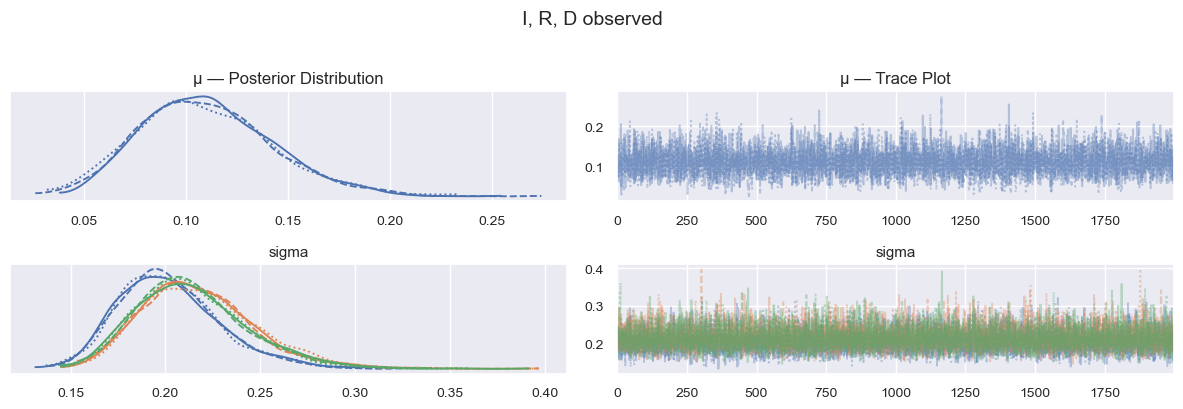

In [18]:
axes = az.plot_trace(trace1)
axes[0, 0].set_title("μ — Posterior Distribution")   # top-left (KDE)
axes[0, 1].set_title("μ — Trace Plot")                # top-right (trace)
plt.suptitle("I, R, D observed", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

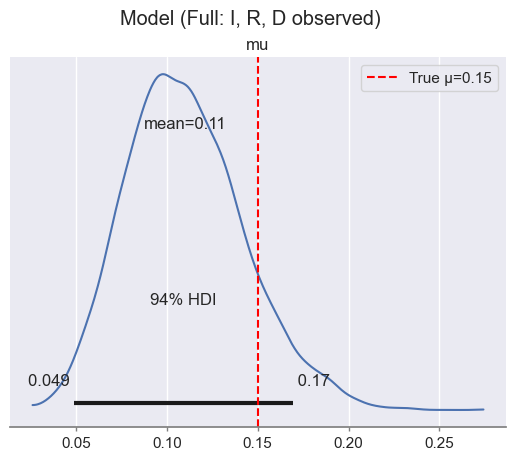

In [19]:
az.plot_posterior(trace1, var_names=["mu"], hdi_prob=0.94)
plt.axvline(mu_true, color='red', linestyle='--', label='True μ=0.15')
plt.suptitle("Model (Full: I, R, D observed)")
plt.legend()

**Step 7: Reduced model - no R observed**

In [21]:
with pm.Model() as model2:
    # ODE system container
    sird_model = DifferentialEquation(
        func = SIRD,
        times = np.arange(0,5*f,timestep_data), # Reverted to plain numpy array for times
        n_states = 4, #r(ecovered) and i(nfected) are states
        n_theta = 1, # beta=R0 only parameter
        t0 = 0 # start from zero
    )

    mu = pm.Lognormal("mu", mu=np.log(0.1), sigma=0.5)
    sigma = pm.HalfCauchy("sigma", 1, shape=3)

    sird_curves = sird_model(
        y0=np.array([s0, i0, r0, d0]), # Changed y0 to a NumPy array for better shape inference
        theta=[mu]
    )
    #R(t) is considered here as not given
    S_hat = sird_curves[:, 0]
    I_hat = sird_curves[:, 1]
    D_hat = sird_curves[:, 3]

    S_like = pm.Normal(
        "S_like",
        mu=S_hat,
        sigma=sigma[0],
        observed=S_obs
    )

    I_like = pm.Normal(
        "I_like",
        mu=I_hat,
        sigma=sigma[1],
        observed=I_obs
    )
    D_like = pm.Normal(
        "D_like",
        mu=D_hat,
        sigma=sigma[2],
        observed=D_obs
    )

In [22]:
with model2:
    trace2 = pm.sample(
        draws=2000,
        tune=1000,
        chains=3,
        target_accept=0.9,
        random_seed=42,
        return_inferencedata=True
    )
print(pm.summary(trace2, var_names=["mu"]).round(2))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (3 chains in 3 jobs)
NUTS: [mu, sigma]


Output()

Sampling 3 chains for 1_000 tune and 2_000 draw iterations (3_000 + 6_000 draws total) took 317 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


    mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
mu   0.1  0.04    0.04     0.17        0.0      0.0    5762.0    3683.0    1.0


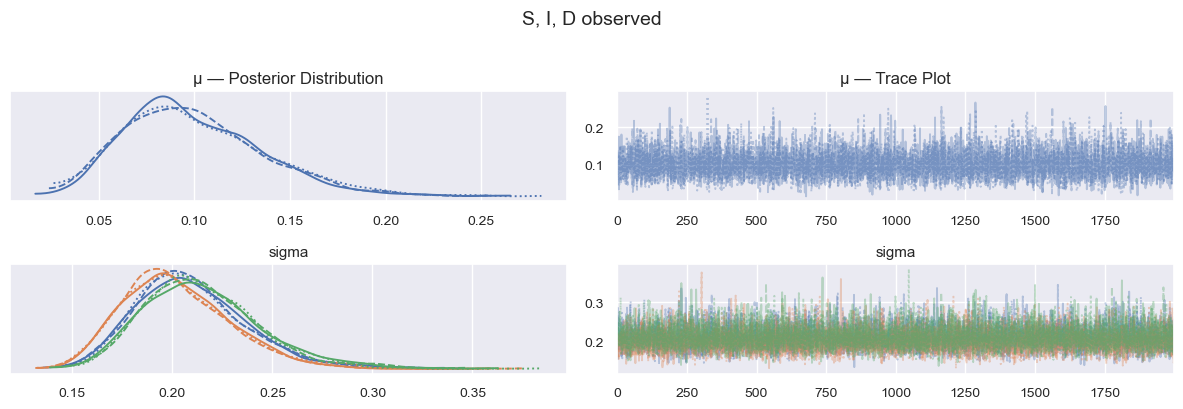

In [23]:
axes = az.plot_trace(trace2)
axes[0, 0].set_title("μ — Posterior Distribution")   # top-left (KDE)
axes[0, 1].set_title("μ — Trace Plot")                # top-right (trace)
plt.suptitle("S, I, D observed", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

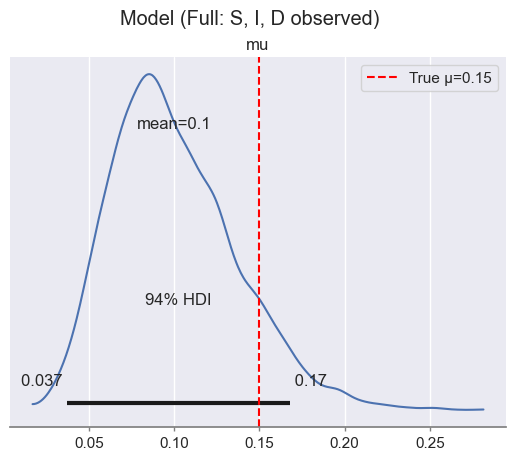

In [24]:
az.plot_posterior(trace2, var_names=["mu"], hdi_prob=0.94)
plt.axvline(mu_true, color='red', linestyle='--', label='True μ=0.15')
plt.suptitle("Model (Full: S, I, D observed)")
plt.legend()

**Step 8: Reduced model - only I and D observed**

In [25]:
with pm.Model() as model3:
    # ODE system container
    sird_model = DifferentialEquation(
        func = SIRD,
        times = np.arange(0,5*f,timestep_data), # Reverted to plain numpy array for times
        n_states = 4, #r(ecovered) and i(nfected) are states
        n_theta = 1, # beta=R0 only parameter
        t0 = 0 # start from zero
    )

    mu = pm.Lognormal("mu", mu=np.log(0.1), sigma=0.5)
    sigma = pm.HalfCauchy("sigma", 1, shape=2)

    sird_curves = sird_model(
        y0=np.array([s0, i0, r0, d0]), # Changed y0 to a NumPy array for better shape inference
        theta=[mu]
    )
    #both S(t) and R(t) are considered here as not given
    I_hat = sird_curves[:, 1]
    D_hat = sird_curves[:, 3]

    I_like = pm.Normal(
        "I_like",
        mu=I_hat,
        sigma=sigma[0],
        observed=I_obs
    )
    D_like = pm.Normal(
        "D_like",
        mu=D_hat,
        sigma=sigma[1],
        observed=D_obs
    )

In [26]:
with model3:
    trace3 = pm.sample(
        draws=2000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        random_seed=42,
        return_inferencedata=True
    )
print(pm.summary(trace3, var_names=["mu"]).round(2))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu, sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 250 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


    mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
mu  0.11  0.04    0.04     0.19        0.0      0.0    3238.0    2276.0    1.0


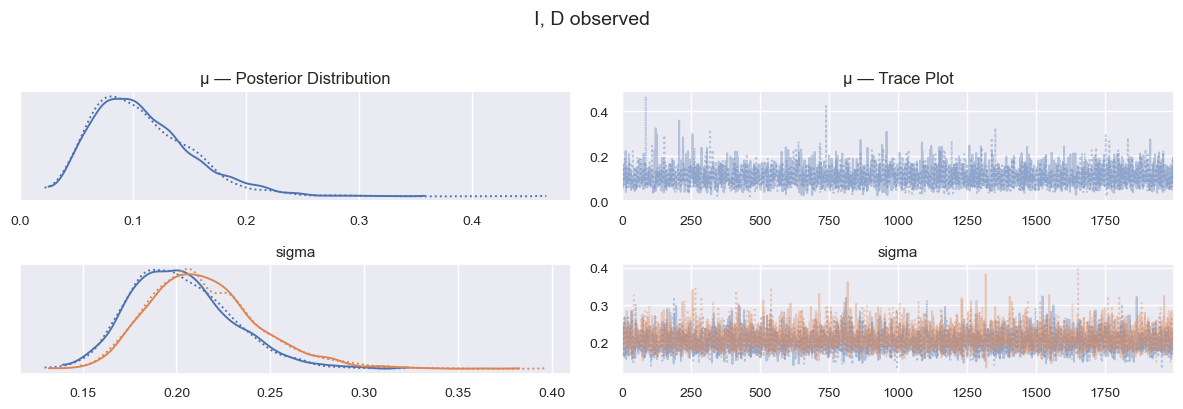

In [27]:
axes = az.plot_trace(trace3)
axes[0, 0].set_title("μ — Posterior Distribution")   # top-left (KDE)
axes[0, 1].set_title("μ — Trace Plot")                # top-right (trace)
plt.suptitle("I, D observed", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

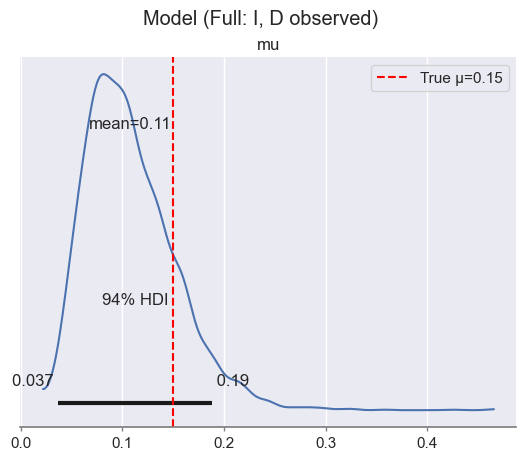

In [28]:
az.plot_posterior(trace3, var_names=["mu"], hdi_prob=0.94)
plt.axvline(mu_true, color='red', linestyle='--', label='True μ=0.15')
plt.suptitle("Model (Full: I, D observed)")
plt.legend()

**Step 9: Comparing all models**

We now compile the posterior summaries from all four models to quantitatively compare how inference quality (mean, SD, HDI width, ESS) degrades as we remove observed compartments.

In [ ]:
summary_full = az.summary(trace, var_names=["mu"])
summary_1 = az.summary(trace1, var_names=["mu"])
summary_2 = az.summary(trace2, var_names=["mu"])
summary_3 = az.summary(trace3, var_names=["mu"])

summary_full["model"] = "S, I, R, D"
summary_1["model"] = "I, R, D"
summary_2["model"] = "S, I, D"
summary_3["model"] = "I, D"

summary_all = pd.concat([summary_full, summary_1, summary_2, summary_3])

summary_all = summary_all.reset_index()[[
    "model", "mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "r_hat"
]]

print(summary_all)

        model   mean     sd  hdi_3%  hdi_97%  ess_bulk  r_hat
0  S, I, R, D  0.124  0.030   0.069    0.182    8040.0    1.0
1     I, R, D  0.110  0.033   0.049    0.170    5678.0    1.0
2     S, I, D  0.100  0.037   0.037    0.168    5762.0    1.0
3        I, D  0.108  0.044   0.037    0.188    3238.0    1.0


- As the number of observed compartments decreases, the **posterior mean shifts from 0.124** (full model) to values around `0.10–0.11` in the reduced models. Meanwhile, the posterior standard deviation increases from `0.030 to 0.044`, indicating growing uncertainty.

- The width of the `94%` HDI expands accordingly, while the effective sample size decreases, reflecting reduced sampling efficiency. However, all models yield posterior intervals that include the true value `μ=0.15`.

**Key Observations and Takeaways**

1. The SIRD model is identifiable from noisy data.
Even with noise `σ = 0.2` added to all compartments, MCMC consistently include the true value `μ ≈ 0.15` in all four experiments, indicating successful inference. The Gelman–Rubin diagnostic `r̂ = 1.0` in every run confirms reliable convergence.

2. μ can be inferred even without S(t) or R(t), dropping S(t), dropping R(t), or dropping both still yields posteriors that cover the true μ. Since D(t) = ∫ μ · I(t) dt, the signal for μ is primarily carried by the D and I compartments. S and R contribute indirectly by constraining the overall epidemic trajectory.

3. Uncertainty grows as observability is reduced
The ordered increase in posterior standard deviation `(0.030 → 0.033 → 0.037 → 0.044 )` and the drop in effective sample size `(8040 → 3238)` are physically meaningful. Less data means a flatter likelihood, so the sampler explores a wider region and mixes less efficiently.

4. The Lognormal prior on μ is appropriate.
The prior `(log-mean = log(0.1), σ = 0.5)` is broad enough not to dominate the posterior, yet it correctly enforces `μ > 0`. The posterior mode shifted clearly away from the prior center toward the true value, confirming the data are informative.

6. MCMC diagnostics are healthy throughout.
All MCSE values are effectively `0.0` relative to the reported precision, and ESS values range from `~3000 to ~8000`, well above the rule-of-thumb threshold of ~400 per chain. No divergences were flagged in any run.